In [22]:
from node import Node
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

digits = load_digits()

X = digits.data
y = digits.target

ss = StandardScaler()
X_scaled = ss.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

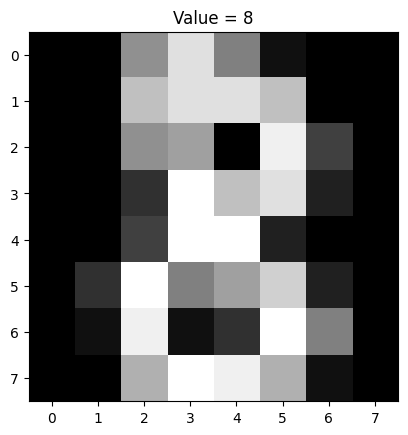

In [33]:
i = 8
plt.imshow(X[i].reshape(8, 8), cmap='grey', interpolation="nearest")
plt.title(f"Value = {y[i]}")
plt.show()

In [ ]:
W1 = Node("W1", np.random.randn(64 + 1, 128) * 0.1)
W2 = Node("W2", np.random.randn(128 + 1, 64) * 0.1)
W3 = Node("W3", np.random.randn(64 + 1, 10) * 0.1)

params = [W1, W2, W3]

def forward(input_v: np.ndarray) -> Node:
    N = len(input_v)
    X1 = Node.concat(input_v, np.ones((N, 1)))
    y1 = Node.sigmoid(Node.matmul(X1, W1))

    X2 = Node.concat(y1, np.ones((N, 1)))
    y2 = Node.sigmoid(Node.matmul(X2, W2))
    
    X3 = Node.concat(y2, np.ones((N, 1)))
    y3 = Node.softmax(Node.matmul(X3, W3))

    return y3

epochs = 100
batch_size = 32
lr = 0.5
for i in range(epochs):
    idx = np.random.permutation(len(X_train))
    X_shuf = X_train[idx]
    y_shuf = y_train[idx]

    tot_loss = 0
    m = 0
    for batch in range(0, len(X_train), batch_size):
        X = X_shuf[batch:batch + batch_size]
        y = y_shuf[batch:batch + batch_size]

        probs = forward(X)
        loss = Node.cross_entropy(probs, y)

        for param in params:
            param.zero_grad()

        tot_loss += loss.value
        loss.backward()

        for param in params:
            param.value -= lr * param.grad

        m += 1
    
    if i % 10 == 0:
        print("Loss:", np.round((tot_loss / m).squeeze(), 4))
        

Loss: 2.2381
Loss: 0.0979
Loss: 0.0411
Loss: 0.0235
Loss: 0.0143
Loss: 0.0101
Loss: 0.0074
Loss: 0.0058
Loss: 0.0047
Loss: 0.0039


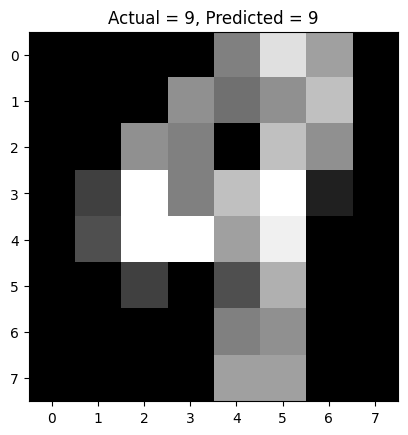

In [105]:
i = 11
probs = forward(np.array([X_test[i]]))
plt.imshow(ss.inverse_transform(X_test[i].reshape(-1, 64)).reshape(8, 8), cmap="grey", interpolation="nearest")
plt.title(f"Actual = {y_test[i]}, Predicted = {probs.value.argmax()}")
plt.show()